In [ ]:
# ================================================================
# CELL 1: Mount Google Drive
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ================================================================
# CELL 2: Extract Dataset and Install
# ================================================================

import zipfile
import os

zip_path = "/content/drive/MyDrive/Research/dataset/dataset_100/dataset.zip"
extract_path = "/content/data/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

DATASET_PATH = "/content/data/dataset"

for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        subfolder = os.path.join(root, d)
        if any(f.endswith('.tif') for f in os.listdir(subfolder)):
            DATASET_PATH = root
            break

print(f"Dataset path: {DATASET_PATH}")
print(f"Classes: {sorted(os.listdir(DATASET_PATH))}")

!pip install rasterio opencv-python cma

Dataset path: /content/data/dataset
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
# ================================================================
# CELL 3: Imports
# ================================================================

import os
import gc
import json
import numpy as np
import rasterio
import cv2
import cma
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

SAVE_DIR = "/content/drive/MyDrive/Research/cmaes_results/multispectral_13band_1000"
MASTER_RESULTS_FILE = "/content/drive/MyDrive/Research/all_experiment_results/master_results.json"
os.makedirs(SAVE_DIR, exist_ok=True)

print("All imports done!")

All imports done!


In [ ]:
# ================================================================
# CELL 4: Load Dataset (13-band, 1000 images)
# ================================================================

IMG_SIZE = 64

def load_13band_image(tif_path):
    with rasterio.open(tif_path) as src:
        if src.count < 13:
            raise ValueError(f"{tif_path} has {src.count} bands, expected 13.")
        img = src.read(list(range(1, 14))).astype(np.float32)
    img = np.transpose(img, (1, 2, 0))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img / 10000.0
    return img

X = []
y = []

class_names = sorted(os.listdir(DATASET_PATH))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("Class mapping:")
for k, v in class_to_idx.items():
    print(f"  {k} → {v}")

for class_name in class_names:
    class_folder = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_folder):
        continue
    label = class_to_idx[class_name]
    for file in os.listdir(class_folder):
        if file.endswith(".tif"):
            img_path = os.path.join(class_folder, file)
            img = load_13band_image(img_path)
            X.append(img)
            y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"\nDataset: X={X.shape}, y={y.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

del X, y, X_temp, y_temp
gc.collect()

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Class mapping:
  AnnualCrop → 0
  Forest → 1
  HerbaceousVegetation → 2
  Highway → 3
  Industrial → 4
  Pasture → 5
  PermanentCrop → 6
  Residential → 7
  River → 8
  SeaLake → 9

Dataset: X=(1000, 64, 64, 13), y=(1000,)
Train: (700, 64, 64, 13)
Validation: (150, 64, 64, 13)
Test: (150, 64, 64, 13)


In [ ]:
# ================================================================
# CELL 5: Model Building Function
# ================================================================

activation_map = {
    0: "relu",
    1: "tanh"
}

def build_cnn_model(
    input_shape,
    num_classes,
    num_conv_layers,
    filters_list,
    kernel_size,
    activation,
    dropout_rate
):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    for i in range(num_conv_layers):
        model.add(
            layers.Conv2D(
                filters=filters_list[i],
                kernel_size=(kernel_size, kernel_size),
                padding="same",
                activation=activation
            )
        )
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation=activation))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model building function ready!")

Model building function ready!


In [ ]:
# ================================================================
# CELL 6: CMA-ES Search Space and Decode Function
# ================================================================

BOUNDS = {
    "num_conv_layers": (1, 3),
    "filters_1": (16, 64),
    "filters_2": (32, 128),
    "filters_3": (64, 256),
    "kernel_size": (3, 5),
    "activation_id": (0, 1),
    "dropout_rate": (0.0, 0.5)
}

def decode_architecture(x):
    num_conv_layers = int(np.clip(round(x[0]), *BOUNDS["num_conv_layers"]))
    filters_1 = int(np.clip(round(x[1]), *BOUNDS["filters_1"]))
    filters_2 = int(np.clip(round(x[2]), *BOUNDS["filters_2"]))
    filters_3 = int(np.clip(round(x[3]), *BOUNDS["filters_3"]))
    kernel_size = int(np.clip(round(x[4]), *BOUNDS["kernel_size"]))
    activation_id = int(np.clip(round(x[5]), *BOUNDS["activation_id"]))
    activation = activation_map[activation_id]
    dropout_rate = float(np.clip(x[6], *BOUNDS["dropout_rate"]))

    filters_list = [filters_1]
    if num_conv_layers > 1:
        filters_list.append(filters_2)
    if num_conv_layers > 2:
        filters_list.append(filters_3)

    return {
        "num_conv_layers": num_conv_layers,
        "filters_list": filters_list,
        "kernel_size": kernel_size,
        "activation": activation,
        "dropout_rate": dropout_rate
    }

print("Search space ready!")

Search space ready!


In [ ]:
# ================================================================
# CELL 7: CMA-ES Search (10 generations, 20 population, 10 epochs)
# ================================================================

x0 = [
    3,      # num_conv_layers (same as baseline)
    32,     # filters conv1
    64,     # filters conv2
    128,    # filters conv3
    3,      # kernel size
    0,      # activation: ReLU
    0.5     # dropout rate
]

sigma = 0.5
POPSIZE = 20
N_GENERATIONS = 10
EPOCHS_PER_CANDIDATE = 10

best_val_accuracy = 0.0
best_architecture = None
all_search_results = []

print("=" * 60)
print("  CMA-ES ARCHITECTURE SEARCH")
print(f"  Config: 13-band Multispectral, 1000 images")
print(f"  Generations: {N_GENERATIONS}, Population: {POPSIZE}")
print(f"  Epochs per candidate: {EPOCHS_PER_CANDIDATE}")
print(f"  Starting from baseline: 3 layers, [32,64,128], relu, drop=0.5")
print("=" * 60)

es = cma.CMAEvolutionStrategy(x0, sigma, {
    "popsize": POPSIZE,
    "verb_log": 0
})

for generation in range(N_GENERATIONS):
    print(f"\n{'='*50}")
    print(f"  Generation {generation+1}/{N_GENERATIONS}")
    print(f"{'='*50}")

    solutions = es.ask()
    fitnesses = []

    for i, x in enumerate(solutions):
        tf.keras.backend.clear_session()
        gc.collect()

        arch = decode_architecture(x)

        print(f"\n--- Candidate {i+1}/{POPSIZE} ---")
        print(f"  Layers: {arch['num_conv_layers']}, Filters: {arch['filters_list']}, "
              f"Kernel: {arch['kernel_size']}, Act: {arch['activation']}, "
              f"Drop: {arch['dropout_rate']:.2f}")

        model = build_cnn_model(
            input_shape=(64, 64, 13),
            num_classes=10,
            num_conv_layers=arch["num_conv_layers"],
            filters_list=arch["filters_list"],
            kernel_size=arch["kernel_size"],
            activation=arch["activation"],
            dropout_rate=arch["dropout_rate"]
        )

        model.fit(
            X_train, y_train,
            epochs=EPOCHS_PER_CANDIDATE,
            batch_size=32,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
        print(f"  Val Accuracy: {val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy = float(val_acc)
            best_architecture = {
                'num_conv_layers': arch['num_conv_layers'],
                'filters_list': arch['filters_list'],
                'kernel_size': arch['kernel_size'],
                'activation': arch['activation'],
                'dropout_rate': arch['dropout_rate']
            }
            model.save(os.path.join(SAVE_DIR, 'best_model_search.h5'))
            print(f"  💾 New best! Saved.")

        fitness = 1.0 - val_acc
        fitnesses.append(fitness)

        all_search_results.append({
            'generation': generation + 1,
            'architecture': arch,
            'val_acc': float(val_acc)
        })

        del model
        gc.collect()

    es.tell(solutions, fitnesses)
    es.disp()
    print(f"\n🏆 Best after Gen {generation+1}: {best_val_accuracy:.4f}")

print(f"\n{'='*60}")
print(f"  🏆 CMA-ES SEARCH COMPLETE")
print(f"{'='*60}")
print(f"  Total architectures evaluated: {len(all_search_results)}")
print(f"  Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"  Best Architecture:")
for k, v in best_architecture.items():
    print(f"    {k}: {v}")

search_data = {
    'config': '13-band Multispectral, 1000 images',
    'generations': N_GENERATIONS,
    'population': POPSIZE,
    'epochs_per_candidate': EPOCHS_PER_CANDIDATE,
    'best_val_accuracy': best_val_accuracy,
    'best_architecture': best_architecture,
    'all_results': all_search_results
}
with open(os.path.join(SAVE_DIR, 'search_results.json'), 'w') as f:
    json.dump(search_data, f, indent=2)
print(f"\n💾 Search results saved!")

  CMA-ES ARCHITECTURE SEARCH
  Config: 13-band Multispectral, 1000 images
  Generations: 10, Population: 20
  Epochs per candidate: 10
  Starting from baseline: 3 layers, [32,64,128], relu, drop=0.5
(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 7 (seed=604072, Mon May 11 08:47:07 2026)

  Generation 1/10

--- Candidate 1/20 ---
  Layers: 3, Filters: [32, 65, 128], Kernel: 3, Act: tanh, Drop: 0.43


  Val Accuracy: 0.7600
  💾 New best! Saved.

--- Candidate 2/20 ---
  Layers: 3, Filters: [32, 64, 129], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.7133

--- Candidate 3/20 ---
  Layers: 3, Filters: [33, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.6267

--- Candidate 4/20 ---
  Layers: 3, Filters: [32, 64, 127], Kernel: 3, Act: tanh, Drop: 0.30
  Val Accuracy: 0.7067

--- Candidate 5/20 ---
  Layers: 3, Filters: [31, 65, 127], Kernel: 3, Act: relu, Drop: 0.09
  Val Accuracy: 0.6800

--- Candidate 6/20 ---
  Layers: 3, Filters: [32, 63, 128], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.7400

--- Candidate 7/20 ---
  Layers: 3, Filters: [33, 63, 128], Kernel: 4, Act: relu, Drop: 0.00
  Val Accuracy: 0.6667

--- Candidate 8/20 ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.39
  Val Accuracy: 0.6400

--- Candidate 9/20 ---
  Layers: 3, Filters: [32, 64, 129], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.7200

--- Candidate 10/20

  Val Accuracy: 0.7733
  💾 New best! Saved.

--- Candidate 12/20 ---
  Layers: 3, Filters: [32, 63, 128], Kernel: 4, Act: relu, Drop: 0.11
  Val Accuracy: 0.7133

--- Candidate 13/20 ---
  Layers: 3, Filters: [33, 65, 127], Kernel: 4, Act: tanh, Drop: 0.08
  Val Accuracy: 0.6400

--- Candidate 14/20 ---
  Layers: 3, Filters: [32, 63, 129], Kernel: 3, Act: relu, Drop: 0.38
  Val Accuracy: 0.7133

--- Candidate 15/20 ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.7533

--- Candidate 16/20 ---
  Layers: 3, Filters: [32, 64, 129], Kernel: 3, Act: tanh, Drop: 0.36
  Val Accuracy: 0.6267

--- Candidate 17/20 ---
  Layers: 2, Filters: [32, 65], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.7200

--- Candidate 18/20 ---
  Layers: 2, Filters: [32, 65], Kernel: 3, Act: relu, Drop: 0.25
  Val Accuracy: 0.6600

--- Candidate 19/20 ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.5800

--- Candidate 20/20 -

  Val Accuracy: 0.7867
  💾 New best! Saved.

--- Candidate 7/20 ---
  Layers: 3, Filters: [31, 65, 127], Kernel: 3, Act: relu, Drop: 0.29
  Val Accuracy: 0.7467

--- Candidate 8/20 ---
  Layers: 3, Filters: [31, 65, 128], Kernel: 4, Act: tanh, Drop: 0.50
  Val Accuracy: 0.7267

--- Candidate 9/20 ---
  Layers: 3, Filters: [32, 64, 129], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.6667

--- Candidate 10/20 ---
  Layers: 3, Filters: [31, 64, 129], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.6400

--- Candidate 11/20 ---
  Layers: 3, Filters: [31, 63, 129], Kernel: 3, Act: tanh, Drop: 0.00
  Val Accuracy: 0.6733

--- Candidate 12/20 ---
  Layers: 3, Filters: [32, 64, 127], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.6867

--- Candidate 13/20 ---
  Layers: 3, Filters: [31, 64, 128], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.6667

--- Candidate 14/20 ---
  Layers: 3, Filters: [32, 65, 129], Kernel: 3, Act: tanh, Drop: 0.00
  Val Accuracy: 0.7000

--- Candidate 

  Val Accuracy: 0.8200
  💾 New best! Saved.

--- Candidate 14/20 ---
  Layers: 2, Filters: [32, 64], Kernel: 4, Act: relu, Drop: 0.00
  Val Accuracy: 0.7333

--- Candidate 15/20 ---
  Layers: 3, Filters: [32, 64, 127], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.6000

--- Candidate 16/20 ---
  Layers: 3, Filters: [32, 64, 127], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.6733

--- Candidate 17/20 ---
  Layers: 2, Filters: [32, 64], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.7733

--- Candidate 18/20 ---
  Layers: 3, Filters: [32, 64, 127], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.7600

--- Candidate 19/20 ---
  Layers: 3, Filters: [31, 65, 128], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.7000

--- Candidate 20/20 ---
  Layers: 3, Filters: [32, 64, 129], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.7267
    6    120 1.800000071525574e-01 2.0e+00 8.67e-01  6e-01  1e+00 27:27.0

🏆 Best after Gen 6: 0.8200

  Generation 7/10

--- Candidate 1/20

In [ ]:
# ================================================================
# CELL 8: Retrain Best CMA-ES Architecture (100 epochs)
# ================================================================

print("=" * 60)
print("  RETRAINING BEST CMA-ES ARCHITECTURE (100 epochs)")
print("=" * 60)

tf.keras.backend.clear_session()
gc.collect()

print(f"Architecture: {best_architecture}")

cmaes_model = build_cnn_model(
    input_shape=(64, 64, 13),
    num_classes=10,
    num_conv_layers=best_architecture['num_conv_layers'],
    filters_list=best_architecture['filters_list'],
    kernel_size=best_architecture['kernel_size'],
    activation=best_architecture['activation'],
    dropout_rate=best_architecture['dropout_rate']
)

cmaes_model.summary()

my_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]

history_cmaes = cmaes_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=my_callbacks,
    verbose=1
)

cmaes_val_loss, cmaes_val_acc = cmaes_model.evaluate(X_val, y_val, verbose=0)
cmaes_test_loss, cmaes_test_acc = cmaes_model.evaluate(X_test, y_test, verbose=0)

print(f"\n📊 CMA-ES Validation Accuracy: {cmaes_val_acc:.4f}")
print(f"📊 CMA-ES Test Accuracy:       {cmaes_test_acc:.4f}")

y_pred_cmaes = np.argmax(cmaes_model.predict(X_test), axis=1)

cmaes_model.save(os.path.join(SAVE_DIR, 'cmaes_retrained_model.h5'))

cmaes_history = {
    'accuracy': [float(x) for x in history_cmaes.history['accuracy']],
    'val_accuracy': [float(x) for x in history_cmaes.history['val_accuracy']],
    'loss': [float(x) for x in history_cmaes.history['loss']],
    'val_loss': [float(x) for x in history_cmaes.history['val_loss']],
}
with open(os.path.join(SAVE_DIR, 'cmaes_training_history.json'), 'w') as f:
    json.dump(cmaes_history, f)

cmaes_report = classification_report(
    y_test, y_pred_cmaes,
    target_names=class_names,
    digits=4,
    output_dict=True
)

del cmaes_model
gc.collect()

print("✅ CMA-ES retraining complete!")

  RETRAINING BEST CMA-ES ARCHITECTURE (100 epochs)
Architecture: {'num_conv_layers': 3, 'filters_list': [33, 64, 126], 'kernel_size': 3, 'activation': 'relu', 'dropout_rate': 0.0}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 33)     │         3,894 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 33)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        19,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 126)    │        72,702 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 126)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8064)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,032,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,129,278 (4.31 MB)

 Trainable params: 1,129,278 (4.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.2457 - loss: 2.0005 - val_accuracy: 0.4333 - val_loss: 1.4515 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4300 - loss: 1.4631 - val_accuracy: 0.5400 - val_loss: 1.2605 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5486 - loss: 1.2147 - val_accuracy: 0.5467 - val_loss: 1.1856 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5343 - loss: 1.1848 - val_accuracy: 0.5733 - val_loss: 1.1283 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6143 - loss: 1.0299 - val_accuracy: 0.6600 - val_loss: 0.9083 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7043 - loss: 0.8460 - val_accuracy: 0.6267 - val_loss: 0.8578 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6957 - loss: 0.8903 -

✅ CMA-ES retraining complete!


In [ ]:
# ================================================================
# CELL 9: Load Baseline Results and Compare
# ================================================================

print("=" * 60)
print("  COMPARISON: BASELINE vs CMA-ES")
print("  Config: 13-band Multispectral, 1000 images")
print("=" * 60)

with open(MASTER_RESULTS_FILE, 'r') as f:
    master_data = json.load(f)

baseline_entry = next(
    (r for r in master_data['experiments']
     if r['num_bands'] == 13 and r['num_images'] == '1000'),
    None
)

if baseline_entry is None:
    print("❌ Baseline result for 13-band 1000 not found in master table!")
    print("   Run the baseline notebook first.")
else:
    baseline_val_acc = baseline_entry['val_accuracy']
    baseline_test_acc = baseline_entry['test_accuracy']
    baseline_f1 = baseline_entry['macro_f1']

    print("\nCMA-ES CNN Classification Report:")
    print(classification_report(y_test, y_pred_cmaes, target_names=class_names, digits=4))

    print(f"\n{'='*65}")
    print(f"{'Metric':<25} {'Baseline':>12} {'CMA-ES':>12} {'Difference':>12}")
    print("-" * 65)
    print(f"{'Validation Accuracy':<25} {baseline_val_acc:>12.4f} {cmaes_val_acc:>12.4f} {cmaes_val_acc - baseline_val_acc:>+12.4f}")
    print(f"{'Test Accuracy':<25} {baseline_test_acc:>12.4f} {cmaes_test_acc:>12.4f} {cmaes_test_acc - baseline_test_acc:>+12.4f}")
    print(f"{'Macro F1-Score':<25} {baseline_f1:>12.4f} {cmaes_report['macro avg']['f1-score']:>12.4f} {cmaes_report['macro avg']['f1-score'] - baseline_f1:>+12.4f}")
    print("-" * 65)

    if 'per_class_f1' in baseline_entry:
        print(f"\n{'Class':<20} {'Baseline F1':>12} {'CMA-ES F1':>12} {'Diff':>12}")
        print("-" * 56)
        for cls in class_names:
            b = baseline_entry['per_class_f1'].get(cls, 0)
            c = cmaes_report[cls]['f1-score']
            print(f"{cls:<20} {b:>12.4f} {c:>12.4f} {c - b:>+12.4f}")

    print(f"\n  Baseline architecture: 3 layers, [32,64,128], kernel 3, relu, dropout 0.5")
    print(f"  CMA-ES architecture:  {best_architecture['num_conv_layers']} layers, "
          f"{best_architecture['filters_list']}, kernel {best_architecture['kernel_size']}, "
          f"{best_architecture['activation']}, dropout {best_architecture['dropout_rate']:.2f}")

  COMPARISON: BASELINE vs CMA-ES
  Config: 13-band Multispectral, 1000 images

CMA-ES CNN Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.8889    0.5333    0.6667        15
              Forest     0.8824    1.0000    0.9375        15
HerbaceousVegetation     0.7500    0.8000    0.7742        15
             Highway     0.7692    0.6667    0.7143        15
          Industrial     1.0000    0.8667    0.9286        15
             Pasture     0.7647    0.8667    0.8125        15
       PermanentCrop     0.5385    0.4667    0.5000        15
         Residential     0.5238    0.7333    0.6111        15
               River     1.0000    1.0000    1.0000        15
             SeaLake     0.9375    1.0000    0.9677        15

            accuracy                         0.7933       150
           macro avg     0.8055    0.7933    0.7913       150
        weighted avg     0.8055    0.7933    0.7913       150


Metric         

In [ ]:
# ================================================================
# CELL 10: Save to Master Results Table
# ================================================================

master_data['cmaes_experiments']['13-band_1000'] = {
    'val_accuracy': float(cmaes_val_acc),
    'test_accuracy': float(cmaes_test_acc),
    'macro_f1': float(cmaes_report['macro avg']['f1-score']),
    'architecture': best_architecture,
    'search_config': {
        'generations': N_GENERATIONS,
        'population': POPSIZE,
        'epochs_per_candidate': EPOCHS_PER_CANDIDATE,
        'total_evaluated': len(all_search_results)
    }
}

with open(MASTER_RESULTS_FILE, 'w') as f:
    json.dump(master_data, f, indent=2)

print(f"💾 CMA-ES results saved to master table!")

print(f"\n{'='*70}")
print("  MASTER TABLE STATUS")
print(f"{'='*70}")
print(f"{'Configuration':<25} {'Baseline Test':>14} {'CMA-ES Test':>12} {'Status':>10}")
print("-" * 70)

cmaes_exps = master_data.get('cmaes_experiments', {})
for r in master_data.get('experiments', []):
    key = f"{r['num_bands']}-band_{r['num_images']}"
    cmaes = cmaes_exps.get(key, {})
    c_test = cmaes.get('test_accuracy')

    c_str = f"{c_test:.4f}" if c_test else "---"
    status = "✅ Done" if c_test else "⏳ Pending"
    label = f"{r['num_bands']}-band, {r['num_images']} imgs"

    print(f"{label:<25} {r['test_accuracy']:>14.4f} {c_str:>12} {status:>10}")

print("-" * 70)

💾 CMA-ES results saved to master table!

  MASTER TABLE STATUS
Configuration              Baseline Test  CMA-ES Test     Status
----------------------------------------------------------------------
3-band, 1000 imgs                 0.6800       0.6733     ✅ Done
13-band, 1000 imgs                0.8267       0.7933     ✅ Done
3-band, 5000 imgs                 0.8067          ---  ⏳ Pending
13-band, 5000 imgs                0.8960          ---  ⏳ Pending
----------------------------------------------------------------------


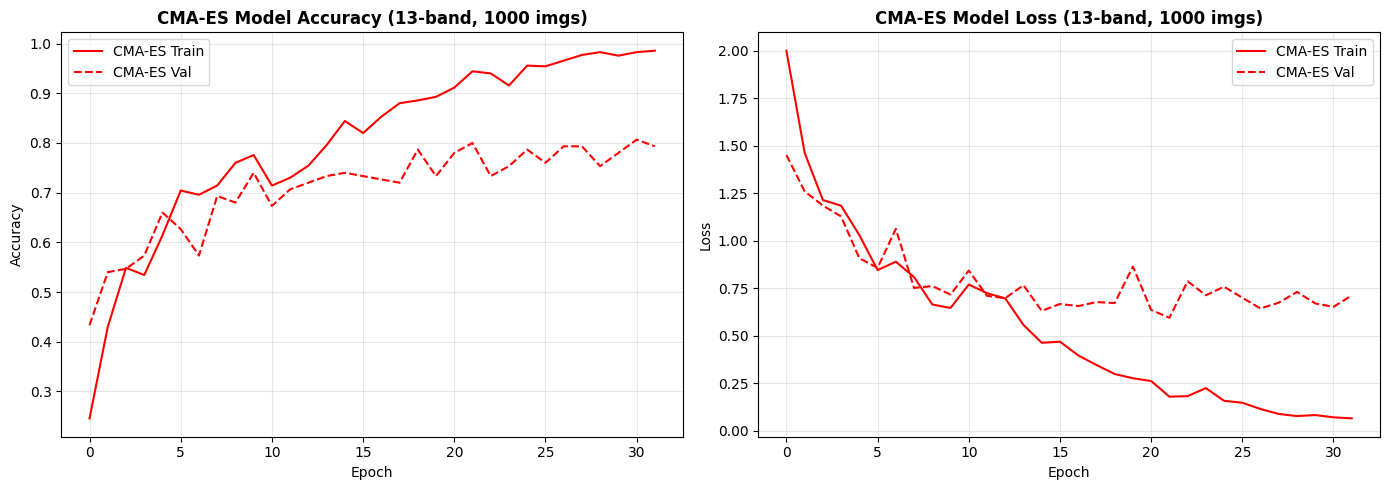

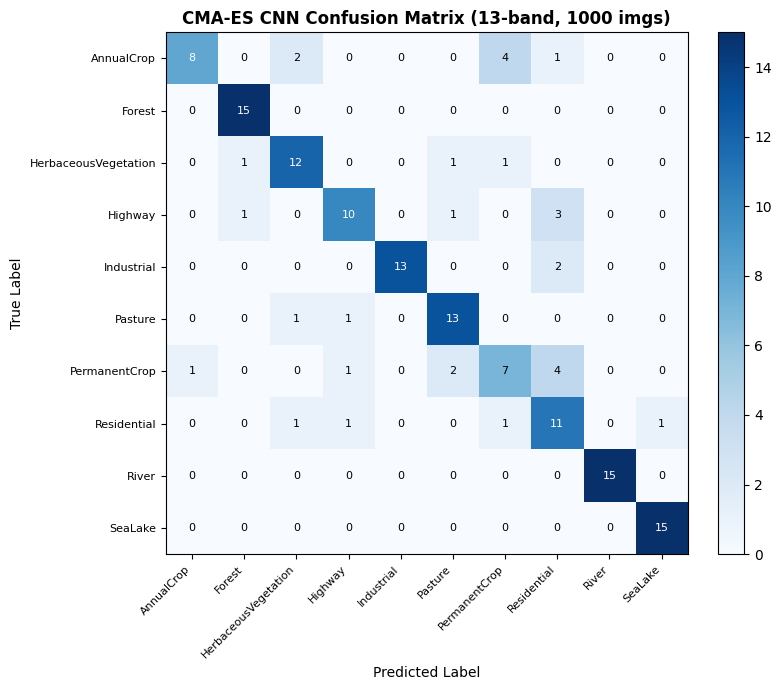

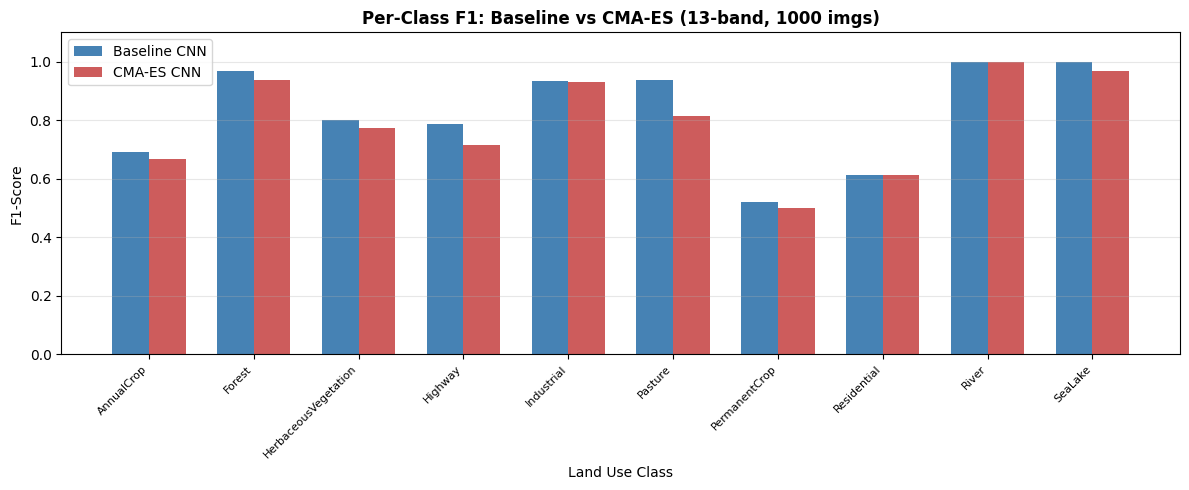

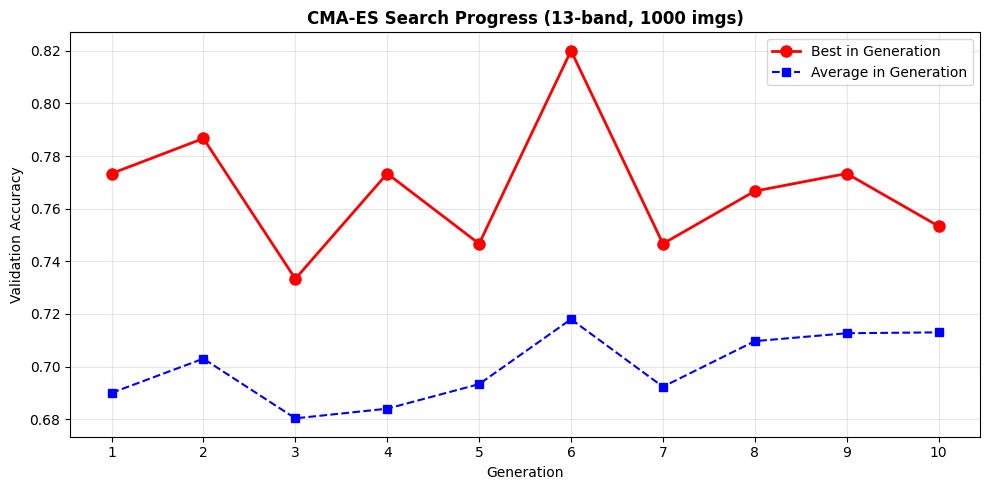


💾 All charts saved to /content/drive/MyDrive/Research/cmaes_results/multispectral_13band_1000


In [ ]:
# ================================================================
# CELL 11: Generate Charts
# ================================================================

# ---- Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cmaes_history['accuracy'], label='CMA-ES Train', linestyle='-', color='red')
axes[0].plot(cmaes_history['val_accuracy'], label='CMA-ES Val', linestyle='--', color='red')
axes[0].set_title('CMA-ES Model Accuracy (13-band, 1000 imgs)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cmaes_history['loss'], label='CMA-ES Train', linestyle='-', color='red')
axes[1].plot(cmaes_history['val_loss'], label='CMA-ES Val', linestyle='--', color='red')
axes[1].set_title('CMA-ES Model Loss (13-band, 1000 imgs)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

# ---- Confusion matrix ----
cm_cmaes = confusion_matrix(y_test, y_pred_cmaes)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_cmaes, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('CMA-ES CNN Confusion Matrix (13-band, 1000 imgs)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

thresh = cm_cmaes.max() / 2.0
for i in range(cm_cmaes.shape[0]):
    for j in range(cm_cmaes.shape[1]):
        ax.text(j, i, format(cm_cmaes[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_cmaes[i, j] > thresh else "black", fontsize=8)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

# ---- Per-class F1 comparison ----
if baseline_entry and 'per_class_f1' in baseline_entry:
    fig, ax = plt.subplots(figsize=(12, 5))

    b_f1 = [baseline_entry['per_class_f1'].get(cls, 0) for cls in class_names]
    c_f1 = [cmaes_report[cls]['f1-score'] for cls in class_names]
    x = np.arange(len(class_names))
    width = 0.35

    ax.bar(x - width/2, b_f1, width, label='Baseline CNN', color='steelblue')
    ax.bar(x + width/2, c_f1, width, label='CMA-ES CNN', color='indianred')
    ax.set_xlabel('Land Use Class')
    ax.set_ylabel('F1-Score')
    ax.set_title('Per-Class F1: Baseline vs CMA-ES (13-band, 1000 imgs)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'per_class_f1.png'), dpi=200, bbox_inches='tight')
    plt.show()

# ---- Search progress ----
fig, ax = plt.subplots(figsize=(10, 5))

gen_numbers = []
gen_best = []
gen_avg = []

for gen in range(1, N_GENERATIONS + 1):
    gen_results = [r for r in all_search_results if r['generation'] == gen]
    if gen_results:
        gen_numbers.append(gen)
        gen_best.append(max(r['val_acc'] for r in gen_results))
        gen_avg.append(np.mean([r['val_acc'] for r in gen_results]))

ax.plot(gen_numbers, gen_best, 'ro-', label='Best in Generation', linewidth=2, markersize=8)
ax.plot(gen_numbers, gen_avg, 'bs--', label='Average in Generation', linewidth=1.5, markersize=6)
ax.set_xlabel('Generation')
ax.set_ylabel('Validation Accuracy')
ax.set_title('CMA-ES Search Progress (13-band, 1000 imgs)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(gen_numbers)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'search_progress.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"\n💾 All charts saved to {SAVE_DIR}")

In [ ]:
# ================================================================
# CELL 12: Final Summary
# ================================================================

b_test = baseline_entry['test_accuracy'] if baseline_entry else 0
b_val = baseline_entry['val_accuracy'] if baseline_entry else 0

print("=" * 60)
print("  COMPLETE RESULTS SUMMARY")
print("  Experiment: CMA-ES, 13-band Multispectral, 1000 images")
print("=" * 60)

print(f"""
DATASET:
  Total images: 1,000 (100 per class)
  Training: {X_train.shape[0]}
  Validation: {X_val.shape[0]}
  Test: {X_test.shape[0]}
  Input shape: (64, 64, 13)
  Classes: 10

CMA-ES SEARCH:
  Generations: {N_GENERATIONS}
  Population: {POPSIZE}
  Epochs per candidate: {EPOCHS_PER_CANDIDATE}
  Architectures evaluated: {len(all_search_results)}
  Best architecture found:
    Layers: {best_architecture['num_conv_layers']}
    Filters: {best_architecture['filters_list']}
    Kernel: {best_architecture['kernel_size']}
    Activation: {best_architecture['activation']}
    Dropout: {best_architecture['dropout_rate']}

BASELINE CNN (from baseline notebook):
  Architecture: 3 layers, [32,64,128], kernel 3, relu, dropout=0.5
  Validation Accuracy: {b_val:.4f}
  Test Accuracy: {b_test:.4f}

CMA-ES CNN (retrained 100 epochs):
  Validation Accuracy: {cmaes_val_acc:.4f}
  Test Accuracy: {cmaes_test_acc:.4f}

IMPROVEMENT:
  Validation: {cmaes_val_acc - b_val:+.4f} ({(cmaes_val_acc - b_val)*100:+.2f}%)
  Test:       {cmaes_test_acc - b_test:+.4f} ({(cmaes_test_acc - b_test)*100:+.2f}%)

FILES SAVED:
  {SAVE_DIR}/search_results.json
  {SAVE_DIR}/best_model_search.h5
  {SAVE_DIR}/cmaes_retrained_model.h5
  {SAVE_DIR}/cmaes_training_history.json
  {SAVE_DIR}/training_curves.png
  {SAVE_DIR}/confusion_matrix.png
  {SAVE_DIR}/per_class_f1.png
  {SAVE_DIR}/search_progress.png
  {MASTER_RESULTS_FILE} (updated)
""")

print("🏁 DONE!")

  COMPLETE RESULTS SUMMARY
  Experiment: CMA-ES, 13-band Multispectral, 1000 images

DATASET:
  Total images: 1,000 (100 per class)
  Training: 700
  Validation: 150
  Test: 150
  Input shape: (64, 64, 13)
  Classes: 10
 
CMA-ES SEARCH:
  Generations: 10
  Population: 20
  Epochs per candidate: 10
  Architectures evaluated: 200
  Best architecture found:
    Layers: 3
    Filters: [33, 64, 126]
    Kernel: 3
    Activation: relu
    Dropout: 0.0
 
BASELINE CNN (from baseline notebook):
  Architecture: 3 layers, [32,64,128], kernel 3, relu, dropout=0.5
  Validation Accuracy: 0.8000
  Test Accuracy: 0.8267
 
CMA-ES CNN (retrained 100 epochs):
  Validation Accuracy: 0.8000
  Test Accuracy: 0.7933
 
IMPROVEMENT:
  Validation: +0.0000 (+0.00%)
  Test:       -0.0333 (-3.33%)
 
FILES SAVED:
  /content/drive/MyDrive/Research/cmaes_results/multispectral_13band_1000/search_results.json
  /content/drive/MyDrive/Research/cmaes_results/multispectral_13band_1000/best_model_search.h5
  /content/drive